# Benchmarking – Scale:

This benchmarking study is supposed to shed light on the behavior of CARVE under varying conditions of dimensionality and sample size in the dataset.

## 1) Imports and Set-Up:

### 1.1) Imports & Seed-Setting:

In [26]:
import multiprocessing
import os
import time

from typing import Any, Dict, List, Tuple, Type

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from joblib import Parallel, delayed
from tqdm.notebook import tqdm

from sklearn.base import ClusterMixin
from sklearn.cluster import AgglomerativeClustering, KMeans, SpectralClustering
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, calinski_harabasz_score, davies_bouldin_score, pairwise_distances, silhouette_score
from sklearn.utils import check_random_state

In [2]:
import sys
print("Interpreter:", sys.executable)

import carve
print("carve from:", carve.__file__)

import inspect
print("Public names:", [n for n in dir(carve) if not n.startswith("_")])
print("Classes:", [n for n, o in inspect.getmembers(carve, inspect.isclass) if o.__module__.startswith("carve")])
print("Functions:", [n for n, o in inspect.getmembers(carve, inspect.isfunction) if o.__module__.startswith("carve")])

Interpreter: /Users/kaiwycik/Documents/GitHub/ClusteringValidation/.venv/bin/python
carve from: /Users/kaiwycik/Documents/GitHub/ClusteringValidation/src/carve/__init__.py
Public names: ['CARVE', 'SpectralClusteringCARVE', 'api', 'cluster', 'grids']
Classes: ['CARVE', 'SpectralClusteringCARVE']
Functions: []


In [3]:
import carve.sim
print("carve.sim from:", carve.sim.__file__)

import inspect
print("Public names:", [n for n in dir(carve.sim) if not n.startswith("_")])
print("Classes:", [n for n, o in inspect.getmembers(carve.sim, inspect.isclass) if o.__module__.startswith("carve.sim")])
print("Functions:", [n for n, o in inspect.getmembers(carve.sim, inspect.isfunction) if o.__module__.startswith("carve.sim")])

carve.sim from: /Users/kaiwycik/Documents/GitHub/ClusteringValidation/src/carve/sim/__init__.py
Public names: ['api', 'simulate_clusters']
Classes: []
Functions: ['simulate_clusters']


We import CARVE:

In [4]:
from carve import CARVE
from carve.config import ValidatorConfig

from carve.sim import simulate_clusters

We set random seeds:

In [5]:
RADNDOM_SEED = 42
np.random.seed(RADNDOM_SEED)
os.environ["PYTHONHASHSEED"] = str(RADNDOM_SEED)

In [6]:
def get_n_jobs():
    # read env override first
    env_val = os.environ.get("CARVE_N_JOBS", None)
    if env_val is not None:
        try:
            return int(env_val)
        except ValueError:
            pass 
        
    # otherwise: default = (num cores - 1)
    try:
        n_cores = multiprocessing.cpu_count()
    except NotImplementedError:
        n_cores = 3

    return max(1, n_cores - 1)

N_JOBS = get_n_jobs()
print(f"Using N_JOBS={N_JOBS} for parallel processing.")

Using N_JOBS=10 for parallel processing.


In [7]:
%env PYTHONWARNINGS=ignore::FutureWarning,ignore::DeprecationWarning,ignore::UserWarning,ignore::RuntimeWarning

env: PYTHONWARNINGS=ignore::FutureWarning,ignore::DeprecationWarning,ignore::UserWarning,ignore::RuntimeWarning


### 1.2) Helper-Functions:

#### 1.2.1) Benchmarking-Helper-Functions:

This function will be used to set the gamma all SpectralClustering estimaros used. We will use the "median heuristic" as outlined by Garreau et al. (2018): https://arxiv.org/abs/1707.07269

In [8]:
def gamma_quantiles_approx(
    X: np.ndarray,
    qs: Tuple[float, ...] = (0.05, 0.10, 0.25, 0.50),
    max_points: int = 500,
    random_state: int = 0,
) -> List[float]:
    """
    approximate spectral rbf gammas using a row-subsample.
    gamma(q) = 1 / (2 * quantile(d^2, q)).
    """
    rng = check_random_state(random_state)
    n = X.shape[0]
    Xs = X[rng.choice(n, size=max_points, replace=False)] if n > max_points else X

    D2 = pairwise_distances(Xs, metric="sqeuclidean")
    d2 = D2[np.triu_indices_from(D2, k=1)]
    d2 = d2[np.isfinite(d2)]
    if d2.size == 0:
        return [1.0 for _ in qs]
    return [float(1.0 / (2.0 * np.quantile(d2, q))) for q in qs]

The following functions implement the **Gap Statistic** method for determining the optimal number of clusters in a dataset.  
They work together to quantify how much better the observed clustering is compared to what would be expected under a reference (null) distribution with no inherent structure.

##### Function 1: `compute_dispersion`
Computes the within-cluster dispersion measure \( W_k \), which quantifies how tightly points are grouped within each cluster.

**Inputs**
- `X` (`np.ndarray`): Data matrix with samples as rows and features as columns.  
- `labels` (`np.ndarray`): Cluster labels for each observation.  
- `metric` (`str`, default `'euclidean'`): Distance metric used to compute pairwise distances within clusters.

**Process**
1. Iterates over all unique cluster labels.  
2. For each cluster, computes all pairwise distances between points.  
3. Averages the total within-cluster distances, normalized by the number of points.  
4. Sums these values across clusters to obtain total within-cluster dispersion.

**Output**
- Returns a single float `W_k`: the total within-cluster dispersion.

##### Function 2: `gen_null`
Generates a reference dataset (null model) by independently sampling each feature from a uniform distribution spanning the observed feature range.

**Inputs**
- `X` (`np.ndarray`): Original dataset.  
- `_` (`int`): Placeholder (unused).  
- `random_state` (`int`): Seed for reproducibility.

**Process**
1. For each feature (column), samples uniformly between its observed minimum and maximum.  
2. Produces a dataset with the same shape as `X` but without clustering structure.

**Output**
- Returns `X_ref` (`np.ndarray`): Null (reference) dataset.

##### Function 3: `gap_statistic`
Computes the Gap Statistic comparing observed clustering dispersion to that expected under the null model.

**Inputs**
- `X` (`np.ndarray`): Data matrix.  
- `labels` (`np.ndarray`): Cluster labels from a fitted clustering algorithm.  
- `metric` (`str`, default `'euclidean'`): Distance metric for dispersion calculation.  
- `n_refs` (`int`, default `10`): Number of reference datasets to generate.  
- `algorithm` (`Type[ClusterMixin]`, default `KMeans`): Clustering algorithm used for reference clustering.  
- `random_state` (`int` or `None`): Random seed for reproducibility.

**Process**
1. Computes observed within-cluster dispersion `W_k`.  
2. Generates `n_refs` null datasets via `gen_null`.  
3. Clusters each null dataset and computes its log-dispersion.  
4. Estimates the expected log-dispersion under the null model.  
5. Computes the Gap Statistic:  
   $$
   \text{Gap}(k) = E[\log(W_k^{\text{null}})] - \log(W_k)
   $$
   Larger gaps indicate more distinct clustering structure than expected by chance.

**Output**
- Returns a single float `gap`: the computed Gap Statistic value for the given clustering configuration.


In [9]:
def compute_dispersion(X: np.ndarray, labels: np.ndarray, metric: str = 'euclidean') -> float:
    """
    Computes the within-cluster dispersion measure W_k for a clustering solution.

    Args:
        X (np.ndarray): Data matrix with samples as rows and features as columns.
        labels (np.ndarray): Cluster labels for each observation.
        metric (str): Distance metric used to compute pairwise distances within clusters (default: 'euclidean').

    Returns:
        float: Total within-cluster dispersion W_k.
    """
    unique_labels = np.unique(labels)
    W_k = 0.0
    
    for label in unique_labels:
        cluster_points = X[labels == label]
        
        if len(cluster_points) <= 1:
            continue
        
        distances = pairwise_distances(cluster_points, metric=metric, squared=True)
        W_k += np.sum(distances) / (2 * cluster_points.shape[0])
    
    return W_k

def gen_null(X: np.ndarray, random_state: int) -> np.ndarray:
    """
    Generates a reference (null) dataset by sampling each feature independently
    from a uniform distribution spanning the observed feature range.

    Args:
        X (np.ndarray): Original dataset.
        random_state (int): Seed for reproducibility.

    Returns:
        np.ndarray: Null (reference) dataset of same shape as X.
    """
    rng = check_random_state(random_state)
    n_samples, p = X.shape
    
    X_ref = np.empty_like(X)
    for j in range(p):
        X_ref[:, j] = rng.uniform(np.min(X[:, j]), np.max(X[:, j]), size=n_samples)
        
    return X_ref

def gap_statistic(
    X: np.ndarray, 
    labels: np.ndarray, 
    metric: str = 'euclidean', 
    n_refs: int = 10, 
    algorithm: Type[ClusterMixin] = KMeans, 
    random_state: str = None
) -> float:
    """
    Computes the Gap Statistic for a clustering solution, comparing observed within-cluster dispersion
    to that expected under a null reference distribution.

    Args:
        X (np.ndarray): Data matrix with samples as rows and features as columns.
        labels (np.ndarray): Cluster labels for each observation.
        metric (str): Distance metric used to compute pairwise distances within clusters (default: 'euclidean').
        n_refs (int): Number of reference datasets to generate (default: 10).
        algorithm (Type[ClusterMixin]): Clustering algorithm used for reference clustering (default: KMeans).
        random_state (str or None): Random seed for reproducibility.

    Returns:
        float: Computed Gap Statistic value for the given clustering configuration.
    """
    num_cores = N_JOBS
    
    rng = check_random_state(random_state)
    W_k = compute_dispersion(X, labels, metric)
    
    # generate and cluster null-models
    def _compute_ref_disp(i: int) -> float:
        X_ref = gen_null(X, rng.randint(0, 1e6))

        k = len(np.unique(labels))
        model = algorithm(n_clusters=k)
        ref_labels = model.fit_predict(X_ref)

        return np.log(compute_dispersion(X_ref, ref_labels, metric))

    ref_log_disps = Parallel(n_jobs=num_cores)(
        delayed(_compute_ref_disp)(i) for i in range(n_refs)
    )
        
    log_W_k = np.log(W_k)
    log_w_k_ref = np.mean(ref_log_disps)
    
    gap = log_w_k_ref - log_W_k
    return gap

`davies_bouldin_inv` computes a normalized, "higher-is-better" variant of the Davies–Bouldin index for a given clustering. It transforms the standard Davies–Bouldin score `db` into

$$
\frac{1}{1 + \textit{Davies–Bouldin Index}}
$$

, so tighter, well-separated clusters yield values closer to 1, while worse clusterings approach 0.

##### Inputs
- `X` (np.ndarray): Data matrix with shape (n_samples, n_features).
- `labels` (np.ndarray): Cluster labels for each sample.

##### What It Computes
1. Calls `davies_bouldin_score(X, labels)` to get `db` (lower is better).
2. Transforms to an increasing metric: `score = 1 / (1 + db)`.
3. If `db` is not finite, returns `np.nan`.

##### Output
- `float`: Inverse Davies–Bouldin score in (0, 1] when finite, else `np.nan`. Higher values indicate more compact and well-separated clusters.


In [10]:
def davies_bouldin_inv(X: np.ndarray, labels: np.ndarray) -> float:
    """
    Computes the inverse Davies-Bouldin index for a clustering solution.

    Args:
        X (np.ndarray): Data matrix with samples as rows and features as columns.
        labels (np.ndarray): Cluster labels for each observation.

    Returns:
        float: Inverse Davies-Bouldin score (1 / (1 + db)), higher is better. Returns np.nan if db is not finite.
    """
    db = davies_bouldin_score(X, labels)
    return 1.0 / (1.0 + db) if np.isfinite(db) else np.nan

`calculate_metric` and `parse_difficulty_and_simulate` are helper functions used to evaluate clustering quality and generate simulated datasets at specified difficulty levels.  
They are designed to support benchmarking of clustering pipelines across a continuum from easy, medium, to difficult settings.

##### Function 1: `calculate_metric`
Dispatches to a chosen clustering validation metric.

**Inputs**
- `X` (`np.ndarray`): Data matrix (samples × features).
- `labels` (`np.ndarray`): Cluster assignments for each sample.
- `metric` (`str`): Which metric to compute. Supported:
  - `'gap'`: Gap Statistic, via `gap_statistic(...)`.
  - `'silhouette'`: Silhouette score, via `silhouette_score(...)`.
  - `'davies_bouldin'`: inverse Davies-Bouldin criterion, via `davies_bouldin_inv(...)`.
  - `'calinski_harabasz'`: Calinski-Harabasz criterion, via `calinski_harabasz_score(...)`.
- `model` (`Type[ClusterMixin]`): Clustering estimator class (used by the Gap Statistic to re-cluster reference datasets).

**Process**
- If `metric == 'gap'`, calls `gap_statistic(X, labels, algorithm=model)`.
- If `metric == 'silhouette'`, calls `silhouette_score(X, labels)`.
- If `metric == 'davies_bouldin'` or `metric == 'DB'`, calls `davies_bouldin_inv(X, labels)`.
- If `metric == 'calinski_harabasz'` or `metric == 'CH'`, calls `calinski_harabasz_score(X, labels)`.
- Otherwise raises `ValueError`.

**Output**
- Returns a single `float` with the requested metric.

##### Function 2: `simulate_scaling`
TODO.

In [11]:
def calculate_metric(X: np.ndarray, labels: np.ndarray, metric: str, model: Type[ClusterMixin], random_state: int = 0) -> float:
    """
    Calculates a clustering validation metric for a given clustering solution.

    Args:
        X (np.ndarray): Data matrix with samples as rows and features as columns.
        labels (np.ndarray): Cluster labels for each observation.
        metric (str): Metric to compute ('gap', 'silhouette', 'davies_bouldin', 'DB', 'calinski_harabasz', 'CH').
        model (Type[ClusterMixin]): Clustering estimator class (used for Gap Statistic reference clustering).

    Returns:
        float: Value of the requested clustering metric.
    """
    if metric == 'gap':
        return gap_statistic(X, labels, algorithm=model, random_state=random_state)

    elif metric == 'silhouette':
        return silhouette_score(X, labels, random_state=random_state)

    elif metric == 'davies_bouldin' or metric == 'DB':
        return davies_bouldin_inv(X, labels)

    elif metric == 'calinski_harabasz' or metric == 'CH':
        return calinski_harabasz_score(X, labels)
    
    else:
        raise ValueError(f"Unknown metric: {metric}")
    
def simulate_scaling(
    *,
    regime: Dict[str, Any],
    true_k: int,
    x_name: str,
    x_value: int,
    seed: int,
    base_random_state: int = 0,
) -> Tuple[np.ndarray, np.ndarray]:
    """
    TODO
    """
    if x_name not in {"n_total", "p"}:
        raise ValueError("x_name must be 'n_total' or 'p'")

    n_total = int(regime.get("n_total", 500))
    p = int(regime.get("p", 100))

    if x_name == "n_total":
        n_total = int(x_value)
    else:
        p = int(x_value)

    X, y, _ = simulate_clusters(
        n_total=n_total,
        p=p,
        k=int(true_k),
        plotting=False,
        random_state=int(base_random_state + seed),
        **{k: v for k, v in regime.items() if k not in {"n_total", "p"}},
    )
    return X, y

`benchmark_scaling` 

TODO.

In [27]:
def make_model_grids(model, test_ks, X=None):
    if model == "agglomerative":
        return [(AgglomerativeClustering, {"n_clusters": list(test_ks), "linkage": ["ward"]})]
    if model == "spectral":
        gamma = gamma_quantiles_approx(X)[3]
        return [(SpectralClustering, {"n_clusters": list(test_ks), "affinity": ["rbf"], "gamma": [gamma]})]
    return [(KMeans, {"n_clusters": list(test_ks)})]

def benchmark_scaling(
    regime,
    x_name,
    B=20,
    model="kmeans",
    true_ks=(3, 4, 5, 6),
    test_ks=range(2, 8),
    external_metrics=("silhouette", "gap", "davies_bouldin", "calinski_harabasz"),
    random_state=0,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    returns:
      df_scores: long-format metric values + selection correctness (as you already do)
      df_runtime: one row per dataset with carve runtime (+ optional external runtime)
    """
    CARVE_AVAILABLE_METRICS = [
        "ari_stability", "ari_generalizability", "ari_average",
        "ari_stability_1se", "ari_generalizability_1se", "ari_average_1se",
        "ari_stability_quant", "ari_generalizability_quant", "ari_average_quant",
        "consensus_pac_stability", "consensus_gini_stability", "consensus_ce_stability",
        "misclassification_generalizability",
    ]

    if x_name == "n_total":
        x_values = [int(x) for x in np.logspace(np.log10(100), np.log10(50000), num=10)]
    elif x_name == "p":
        x_values = [int(x) for x in np.logspace(np.log10(10), np.log10(2500), num=10)]
    else:
        raise ValueError("x_name must be 'n_total' or 'p'")

    scores = []
    runtimes = []

    total_steps = len(x_values) * B * len(true_ks)
    pbar = tqdm(total=total_steps, desc=f"benchmarking scaling ({x_name})", leave=True)

    for x_value in x_values:
        for seed in range(B):
            for true_k in true_ks:
                X, y = simulate_scaling(
                    regime=regime[true_k],
                    true_k=true_k,
                    x_name=x_name,
                    x_value=x_value,
                    seed=seed,
                    base_random_state=random_state
                )

                model_grids = make_model_grids(model=model, test_ks=test_ks, X=X)

                carve = CARVE(
                    model_grids=model_grids,
                    n_jobs=N_JOBS,
                    random_state=seed + random_state,
                )

                t0 = time.perf_counter()
                carve.fit(X, ref_labels=y)
                t_carve = time.perf_counter() - t0

                for carve_metric in CARVE_AVAILABLE_METRICS:
                    if carve_metric.endswith("_quant"):
                        rule = "quantile"
                        measure = carve_metric[:-6]
                    elif carve_metric.endswith("_1se"):
                        rule = "1se"
                        measure = carve_metric[:-4]
                    else:
                        rule = "max"
                        measure = carve_metric

                    optimal_k = carve.get_optimal_k(measure=measure, rule=rule)

                    for k in test_ks:
                        value = carve.model_df_.loc[carve.model_df_["n_clusters"] == k, measure].values[0]
                        scores.append({
                            x_name: x_value,
                            "metric_name": carve_metric,
                            "true_k": true_k,
                            "k": k,
                            "metric_value": value,
                            "is_optimal": (k == optimal_k),
                            "is_correct": (k == true_k),
                            "dataset_id": seed,
                        })
                                
                # time external metric pass separately
                t1 = time.perf_counter()
                
                for metric in external_metrics:
                    metric_values = []
                    for k in test_ks:
                        labels = carve.get_optimal_labels(k=k)
                        
                        value = calculate_metric(
                            X, labels, metric,
                            model=model_grids[0][0],
                            random_state=seed + random_state
                        )
                        metric_values.append((k, value))

                    optimal_k, _ = max(metric_values, key=lambda x: x[1])
                    for k, value in metric_values:
                        scores.append({
                            x_name: x_value,
                            "metric_name": metric,
                            "true_k": true_k,
                            "k": k,
                            "metric_value": value,
                            "is_optimal": (k == optimal_k),
                            "is_correct": (k == true_k),
                            "dataset_id": seed,
                        })

                t_external = time.perf_counter() - t1

                runtimes.append({
                    x_name: x_value,
                    "true_k": true_k,
                    "dataset_id": seed,
                    "n": X.shape[0],
                    "p": X.shape[1],
                    "B": B,
                    "n_jobs": N_JOBS,
                    "n_test_ks": len(list(test_ks)),
                    "model": model,
                    "t_carve_sec": t_carve,
                    "t_carve_per_k_sec": t_carve / len(list(test_ks)),
                    "t_external_sec": t_external,  # keep or drop
                })

                pbar.update(1)

    pbar.close()
    return pd.DataFrame(scores), pd.DataFrame(runtimes)

#### 1.2.2) Plotting-Helper-Functions:

`plot_examples` 

TODO.

In [60]:
def plot_scaling_examples(
    regime: Dict,
    x_name: str,
    ks: np.ndarray = np.array([3, 4, 5, 6]),
    B: int = 10,
    random_state: int = 0,
    estimator_type: str = 'hierarchical',
    name_of_ex: str = 'Scaling Benchmark'
) -> None:
    """
    TODO
    """
    if x_name == "n_total":
        x_values = [int(x) for x in np.logspace(np.log10(100), np.log10(50000), num=3)]
    elif x_name == "p":
        x_values = [int(x) for x in np.logspace(np.log10(10), np.log10(2500), num=3)]
    else:
        raise ValueError("x_name must be 'n_total' or 'p'")

    _, axes = plt.subplots(len(ks), len(x_values), figsize=(3 * len(x_values), 3 * len(ks)))
    for i, k in enumerate(ks):
        for j, x_value in enumerate(x_values):
            # Simulate dataset to be displayed
            X, y = simulate_scaling(
                regime=regime[k],
                true_k=k,
                x_name=x_name,
                x_value=x_value,
                seed=1 * 10 + j,
                base_random_state=random_state
            )

            # Compute baseline ARI over B replicates
            ari_arr = []
            for b in range(B):
                X_val, y_val = simulate_scaling(
                    regime=regime[k],
                    true_k=k,
                    x_name=x_name,
                    x_value=x_value,
                    seed=i * 100 + j * 10 + b,
                    base_random_state=random_state
                )

                if estimator_type == 'hierarchical':
                    estimator = AgglomerativeClustering(n_clusters=k)
                elif estimator_type == 'kmeans':
                    estimator = KMeans(n_clusters=k, random_state=random_state)
                elif estimator_type == 'spectral':
                    gamma = gamma_quantiles_approx(X)[3]
                    estimator = SpectralClustering(n_clusters=k, affinity='rbf', gamma=gamma, random_state=random_state)
                else:
                    raise ValueError("estimator_type must be 'hierarchical' or 'spectral'")

                y_hat_val = estimator.fit_predict(X_val)
                ari = adjusted_rand_score(y_val, y_hat_val)
                ari_arr.append(ari)

            ari_mean = np.mean(ari_arr)

            # Plot PCA of dataset
            X_pca = PCA(n_components=2, random_state=0).fit_transform(X)
            ax = axes[i, j]
            ax.scatter(
                X_pca[:, 0], X_pca[:, 1],
                c=y, cmap="tab10", s=20, alpha=0.8, edgecolors="k"
            )
            ax.set_title(f"k={k}, {x_name}={x_value} | ARI={ari_mean:.3f}")
            ax.set_xticks([]); ax.set_yticks([])

    plt.suptitle(f"Scaling Benchmark: {name_of_ex}", fontsize=16)
    plt.tight_layout(); plt.show()


`plot_accuracy_vs_difficulty` plots how often each metric selects the correct number of clusters as difficulty increases. Accuracy is computed per dataset, then summarized across replicates for each difficulty and metric, and finally visualized as mean accuracy curves with optional uncertainty bands.

##### Inputs
- `results_df` (pandas DataFrame): Long-form results with at least the columns  
  `difficulty`, `metric_name`, `dataset_id`, `is_optimal`, `is_correct`.  
  Typically produced by the benchmarking routines.
- `show_se` (bool, default False): If True, shades an uncertainty band around the mean.  
  Note: the band is mean ± standard deviation as computed, not the standard error.

##### What It Computes
1. Filters to rows where `is_optimal` is True (the k chosen by each metric for that dataset).
2. For each `(difficulty, metric_name, dataset_id)`, computes the mean of `is_correct`.  
   This yields an accuracy per dataset replicate.
3. For each `(difficulty, metric_name)`, aggregates replicate accuracies into  
   mean and standard deviation.
4. Produces a line for each `metric_name` showing mean accuracy versus `difficulty`.  
   If `show_se` is True, fills a band using mean ± std.

##### Plot Details
- X-axis: `difficulty` (integer index of problem difficulty).
- Y-axis: mean accuracy (fraction of datasets where the metric picked the true k).
- Lines: one per `metric_name`, with circular markers.
- Optional shaded area: mean ± std across `dataset_id` replicates (when `show_se=True`).
- Grid and legend included for readability.

##### Output
- Returns nothing. Displays a Matplotlib figure with accuracy curves by metric.


In [ ]:
def plot_accuracy_vs_difficulty(
    results_df: pd.DataFrame, 
    show_se: bool = False
) -> None:
    """
    Plots the accuracy of clustering metrics as a function of problem difficulty.

    Args:
        results_df (pd.DataFrame): DataFrame containing benchmarking results with columns
            ['difficulty', 'metric_name', 'is_optimal', 'is_correct', 'dataset_id'].
        show_se (bool, optional): If True, displays standard error bands around the mean accuracy.

    Returns:
        None. Displays a line plot of accuracy vs. difficulty for each metric.
    """
    accuracy_df = (
        results_df[results_df['is_optimal']]
            .groupby(['difficulty', 'metric_name', 'dataset_id'])
            .agg({'is_correct': 'mean'})
            .reset_index()
            .groupby(['difficulty', 'metric_name'])
            .agg({'is_correct': ['mean', 'std']})
            .reset_index()
    )
    
    # Plot
    plt.figure(figsize=(12, 8))
    for metric in accuracy_df['metric_name'].unique():
        subset = accuracy_df[accuracy_df['metric_name'] == metric]
        plt.plot(subset['difficulty'], subset[('is_correct', 'mean')], marker='o', label=metric)
        if show_se:
            plt.fill_between(
                subset['difficulty'],
                subset[('is_correct', 'mean')] - subset[('is_correct', 'std')],
                subset[('is_correct', 'mean')] + subset[('is_correct', 'std')],
                alpha=0.2
        )
    
    plt.xlabel('Difficulty (difficulty)')
    plt.ylabel('Accuracy')
    plt.title('Metric Accuracy vs. Problem Difficulty')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

`plot_metric_lineplots_grid` builds a grid of line plots that summarize metric values across candidate k for selected difficulty anchors and true_k rows. Each subplot shows the mean metric value vs k for several metrics, with optional majority-vote markers that indicate which k a metric most often selects under two rules (max and 1se), including an agreement marker when both rules pick the same k.

##### Inputs
- `results_df` (DataFrame): Long results table with columns including `true_k`, `k`, `difficulty`, `metric_name`, `metric_value`, and optionally `is_optimal`.
- `difficulties` (list-like): Ordered list of difficulty indices; the first, middle, and last are used as anchors.
- `metrics_to_display` (list or None): Optional filter of metric names to plot. Metrics ending with `_1se` are excluded from the lines (their votes are shown via markers).
- `show_majority_votes` (bool, default True): If True, overlays vote markers for max and 1se rules and an agreement star when both rules pick the same k.
- `figsize` (tuple or None): Figure size `(width, height)`. Defaults to `(3.5 * num_anchors, 2.5 * num_true_k)`.

##### What It Plots
- Rows correspond to `true_k` values found in `results_df`.
- Columns correspond to difficulty anchors: first, middle, and last of `difficulties`.
- For each subplot:
  - For each base metric (not ending in `_1se`), plots the mean of `metric_value` vs `k`, with circular markers.
  - The plotted mean curves are min–max normalized to [0, 1] within each `(true_k, difficulty, metric_name)` group.
  - Optionally overlays vote markers:
    - Diamond at the k chosen most often by the base metric under the max rule (ties break to the largest k).
    - X at the k chosen most often by the paired `_1se` variant under the 1se rule (ties break to the largest k).
    - Star above the curve if both rules choose the same k (agreement).

##### Special Handling of Paired Metrics
- The function treats these pairs as related:
  - `ari_stability` with `ari_stability_1se`
  - `ari_generalizability` with `ari_generalizability_1se`
- Lines are drawn only for the base metrics (`ari_stability`, `ari_generalizability`), while vote markers can appear for both the base and the `_1se` partner.
- The agreement star is shown only when both rules select the same k.

##### Data Processing Details
- Casts `is_optimal` to int when present (numeric safety).
- Uses a tolerance-based mask to match continuous `difficulty` values to chosen anchors.
- Averages `metric_value` over replicates at each `(true_k, difficulty, k, metric_name)` to produce the line curves.
- Applies per-metric, per-subplot min–max scaling of the mean values to [0, 1] before plotting.
- Majority votes are computed by summing `is_optimal` within `(true_k, difficulty, metric_name, k)` and taking the k with the highest count; ties resolve to the largest k.

##### Axes, Labels, and Guides
- Vertical dashed guide at the row’s `true_k`.
- Column titles show `alpha = <difficulty>` using the numeric difficulty at that column.
- Y-axis label per row: `true_k = <value>`. X-axis label: `k`.
- X-limits expand to cover the observed min and max k with a small margin.
- Grid lines and a shared legend are included. The legend includes:
  - Line labels for each base metric.
  - Optional markers for vote annotations: diamond (max rule), x (1se rule), star (agreement).

##### Output
- Returns nothing. Displays a Matplotlib figure with a grid of line plots, one column per difficulty anchor and one row per true_k.


In [ ]:
def plot_metric_lineplots_grid(
    results_df: pd.DataFrame,
    difficulties: List[float],
    metrics_to_display: List[str] = None,
    show_majority_votes: bool = True,
    figsize: Tuple[float, float] = None
) -> None:
    """
    Plots a grid of line plots for clustering metrics across different difficulties and true_k values.

    Args:
        results_df (pd.DataFrame): DataFrame containing clustering results with columns:
            ['true_k', 'k', 'difficulty', 'metric_name', 'metric_value', ...].
        difficulties (List[float]): List of difficulty values to anchor the grid columns.
        metrics_to_display (Optional[List[str]]): List of metric names to plot. If None, all available metrics are used.
        show_majority_votes (bool): If True, displays majority vote markers (diamond, star, cross) for optimal k selection.
        figsize (Optional[Tuple[float, float]]): Figure size for the plot. If None, size is determined automatically.

    Returns:
        None. Displays the matplotlib figure.
    """
    PAIRED = {
        "ari_stability_1se": "ari_stability",
        "ari_generalizability_1se": "ari_generalizability",
    }
    
    BASE_WITH_PAIR = set(PAIRED.values())  # metrics that have a 1se partner

    # numeric safety
    results_df = results_df.copy()
    if 'is_optimal' in results_df.columns:
        results_df['is_optimal'] = results_df['is_optimal'].astype(int)

    anchors = [difficulties[0], difficulties[len(difficulties)//2], difficulties[-1]]

    all_metrics = sorted(results_df['metric_name'].unique())
    if metrics_to_display is not None:
        metrics = [m for m in metrics_to_display if (m in all_metrics) and (m not in PAIRED.keys())]
        if not metrics:
            raise ValueError(f"None of the provided metrics {metrics_to_display} found in data")
    else:
        metrics = [m for m in all_metrics if m not in PAIRED.keys()]

    true_ks = sorted(results_df['true_k'].unique())

    if figsize is None:
        figsize = (3.5*len(anchors), 2.5*len(true_ks))

    fig, axes = plt.subplots(len(true_ks), len(anchors), figsize=figsize)

    if len(true_ks) == 1:
        axes = np.array([axes])
    if len(anchors) == 1:
        axes = np.array([axes]).T

    def difficulty_mask(series, a):
        return np.isclose(series.to_numpy(dtype=float), float(a), rtol=1e-6, atol=1e-8)

    for i, true_k in enumerate(true_ks):
        for j, difficulty in enumerate(anchors):
            ax = axes[i, j]
            line_y = {}

            # plot each (base) metric line
            for metric in metrics:
                subset_mask = (
                    (results_df['true_k'] == true_k) &
                    (results_df['metric_name'] == metric) &
                    difficulty_mask(results_df['difficulty'], difficulty)
                )
                subset = results_df.loc[subset_mask]
                if subset.empty:
                    continue

                avg_df = (
                    subset.groupby('k')['metric_value']
                        .agg(mean='mean', std='std')
                        .reset_index()
                )
                mean_values = avg_df['mean'].to_numpy()
                
                min_val = np.min(mean_values)
                max_val = np.max(mean_values)
                mean_values = (mean_values - min_val) / (max_val - min_val)

                ax.plot(avg_df['k'], mean_values, marker='o', label=metric)
                line_y[metric] = dict(zip(avg_df['k'].to_numpy(), mean_values))

                if show_majority_votes and 'is_optimal' in subset.columns and metric not in BASE_WITH_PAIR:
                    votes = subset.groupby('k')['is_optimal'].sum().sort_values(ascending=False)
                    if not votes.empty:
                        k_base_vote = int(votes[votes == votes.iloc[0]].index.max())  # if tie, then largest k
                        if k_base_vote in line_y[metric]:
                            y_on_curve = float(line_y[metric][k_base_vote])
                            ax.scatter(
                                [k_base_vote], [y_on_curve], marker='D', s=70,
                                edgecolors='black', facecolors='white',
                                zorder=5, label=None
                            )

            # handle paired markers with agreement logic
            if show_majority_votes:
                for excl_metric, base_metric in PAIRED.items():
                    excl_mask = (
                        (results_df['true_k'] == true_k) &
                        (results_df['metric_name'] == excl_metric) &
                        difficulty_mask(results_df['difficulty'], difficulty)
                    )
                    base_mask = (
                        (results_df['true_k'] == true_k) &
                        (results_df['metric_name'] == base_metric) &
                        difficulty_mask(results_df['difficulty'], difficulty)
                    )
                    excl_subset = results_df.loc[excl_mask]
                    base_subset = results_df.loc[base_mask]
                    if excl_subset.empty or base_subset.empty:
                        continue
                    if 'is_optimal' not in excl_subset.columns or 'is_optimal' not in base_subset.columns:
                        continue

                    # votes (consistent tie rule: largest k)
                    excl_votes = excl_subset.groupby('k')['is_optimal'].sum().sort_values(ascending=False)
                    base_votes = base_subset.groupby('k')['is_optimal'].sum().sort_values(ascending=False)
                    if excl_votes.empty or base_votes.empty:
                        continue

                    k_excl_vote = int(excl_votes[excl_votes == excl_votes.iloc[0]].index.max())
                    k_base_vote = int(base_votes[base_votes == base_votes.iloc[0]].index.max())

                    # y anchors from the base metric curve
                    y_map = line_y.get(base_metric, {})
                    if not y_map:
                        continue
                    # require the y for at least the locations we will plot
                    if (k_base_vote not in y_map) and (k_excl_vote not in y_map):
                        continue

                    if k_base_vote == k_excl_vote:
                        y_star = float(y_map.get(k_base_vote, list(y_map.values())[0]))
                        y_star += 0.02
                        ax.scatter([k_base_vote], [y_star], marker='*', s=220,
                                   facecolors='none', edgecolors='black',
                                   linewidths=2.0, zorder=8, label=None)
                    else:
                        # draw ◇ at base vote
                        if k_base_vote in y_map:
                            y_d = float(y_map[k_base_vote])
                            ax.scatter(
                                [k_base_vote], [y_d], marker='D', s=70,
                                edgecolors='black', facecolors='white',
                                zorder=6, label=None
                            )

                        if k_excl_vote in y_map:
                            y_x = float(y_map[k_excl_vote]) + 0.025
                            ax.scatter(
                                [k_excl_vote], [y_x], marker='x', s=90,
                                color='black', linewidths=2, zorder=7, label=None
                            )

            # guides / labels
            ax.axvline(true_k, color='gray', linestyle='--', alpha=0.5)
            if i == 0:
                ax.set_title(f'α = {difficulty:.3f}')
            if j == 0:
                ax.set_ylabel(f'true_k = {true_k}')
            ax.set_xlabel('k')
            ax.grid(True, alpha=0.3)

            k_values = results_df['k'].unique()
            ax.set_xlim(min(k_values) - 0.5, max(k_values) + 0.5)

    # legend
    handles, labels = axes[0, 0].get_legend_handles_labels()
    if show_majority_votes:
        handles += [
            Line2D(
                [0],[0], marker='D', linestyle='None',
                markerfacecolor='white', markeredgecolor='black', label='max rule (vote)'
            ),
            Line2D(
                [0],[0], marker='x', linestyle='None',
                color='black', label='1se rule (vote)'
            ),
            Line2D(
                [0],[0], marker='*', linestyle='None',
                markerfacecolor='none', markeredgecolor='black', label='agree (vote)'
            ),
        ]
        labels += ['max rule (vote)', '1se rule (vote)', 'agree (vote)']

    fig.legend(
        handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.02),
        fancybox=True, shadow=True, ncol=min(5, max(1, len(metrics)))
    )

    plt.tight_layout(rect=[0, 0.05, 1, 0.97])
    plt.subplots_adjust(wspace=0.3, hspace=0.3)
    plt.show()

`print_summary_stats` prints a compact accuracy summary for clustering metrics across difficulty levels. It filters to rows where a metric actually selected a k (`is_optimal == True`), computes accuracy per `(difficulty, metric_name)`, marks the best metric per difficulty with a star, and reports an overall ranking aggregated across all difficulties.

##### Inputs
- `results_df` (pandas DataFrame): Benchmark results with columns including  
  `difficulty`, `metric_name`, `is_optimal`, `is_correct`, and optionally others.

##### What It Computes
- Per `(difficulty, metric_name)`:
  - Mean accuracy: average of `is_correct`.
  - Standard deviation of accuracy across dataset replicates.
  - Count of contributing rows.
- A star marker for the metric with the highest mean accuracy within each difficulty (ties resolved by groupby idxmax semantics).
- An overall summary across all difficulties:
  - Mean accuracy and standard deviation for each `metric_name`.
  - A descending ranking by mean accuracy.

##### Process
1. Filter to `is_optimal == True` so that each metric contributes only where it made a selection for that dataset.
2. Group by `(difficulty, metric_name)` and compute mean, std, and count on `is_correct`.
3. Identify the per-difficulty winner and tag it with `*`.
4. Format a string cell per metric and difficulty as `mean+/-std` with the star appended when applicable.
5. Pivot to a grid with metrics as rows and difficulty values as columns for readable printing.
6. Compute an overall table by aggregating across all difficulties, then sort for a ranked list.

##### Printed Report
1. Header: `Accuracy (mean+/-std)`  
   - A string grid where each cell is `mean+/-std` (e.g., `0.812+/-0.045`) and, for difficulty winners, `0.845+/-0.030*`.
2. Header: `Overall ranking (aggregated over all difficulties and k)`  
   - A numbered list of metrics with `mean +/- std` and sample size `n`.

##### Output
- Returns nothing. Writes the formatted tables to standard output for quick inspection and comparison of metric performance.


In [ ]:
def print_summary_stats(results_df: pd.DataFrame) -> None:
    """
    Prints a summary table of clustering metric accuracy statistics.

    Args:
        results_df (pd.DataFrame): DataFrame containing benchmarking results with columns
            ['difficulty', 'metric_name', 'is_optimal', 'is_correct', ...].

    Returns:
        None. Displays formatted accuracy statistics per metric and difficulty, and overall ranking.
    """
    df = results_df.loc[results_df['is_optimal']].copy()

    # --- per-(difficulty, metric) stats
    g = (
        df.groupby(['difficulty', 'metric_name'])['is_correct']
            .agg(mean='mean', std='std', n='count')
            .reset_index()
    )
    g['std'] = g['std'].fillna(0.0)

    difficulties = sorted(g['difficulty'].unique())

    # --- star best per difficulty
    stars = (
        g.loc[g.groupby('difficulty')['mean'].idxmax(), ['difficulty', 'metric_name']]
            .set_index(['difficulty', 'metric_name'])
            .assign(star='*')
    )

    # helper to format "m ± s" and add star
    def _fmt(row):
        key = (row['difficulty'], row['metric_name'])
        star = stars.loc[key, 'star'] if key in stars.index else ''
        return f"{row['mean']:.3f}±{row['std']:.3f}{star}"

    g['cell'] = g.apply(_fmt, axis=1)

    # --- pretty grid (string view)
    grid = (
        g.pivot(index='metric_name', columns='difficulty', values='cell')
            .reindex(columns=difficulties)
    )

    # # --- overall across all alpha & k
    overall = (
        df.groupby('metric_name')['is_correct']
            .agg(mean='mean', std='std', n='count')
    )
    overall['std'] = overall['std'].fillna(0.0)

    # print 
    print("\n=== Accuracy (mean±std)")
    # align columns by width
    with pd.option_context('display.max_columns', None, 'display.width', 160):
        print(grid.fillna('').sort_index())

    # overall ranking block
    print("\n=== Overall ranking (aggregated over all α & k) ===")
    ranked = overall.sort_values('mean', ascending=False)
    for i, (metric, r) in enumerate(ranked.iterrows(), start=1):
        print(f"{i:>2}. {metric:<20} {r['mean']:.3f} ± {r['std']:.3f}  (n={int(r['n'])})")


---

## 2) Benchmarking:

### 2.1) Dimensionality Benchmark:

#### Gaussians:

In [20]:
regime_gaussian = {
    3: {"cluster_scale": [6] * 3, 'cluster_size_dirichlet_alpha': 0.5, 'balanced': False},
    4: {"cluster_scale": [5] * 4, 'cluster_size_dirichlet_alpha': 0.5, 'balanced': False},
    5: {"cluster_scale": [4] * 5, 'cluster_size_dirichlet_alpha': 0.5, 'balanced': False},
    6: {"cluster_scale": [3.5] * 6, 'cluster_size_dirichlet_alpha': 0.5, 'balanced': False}, 
}


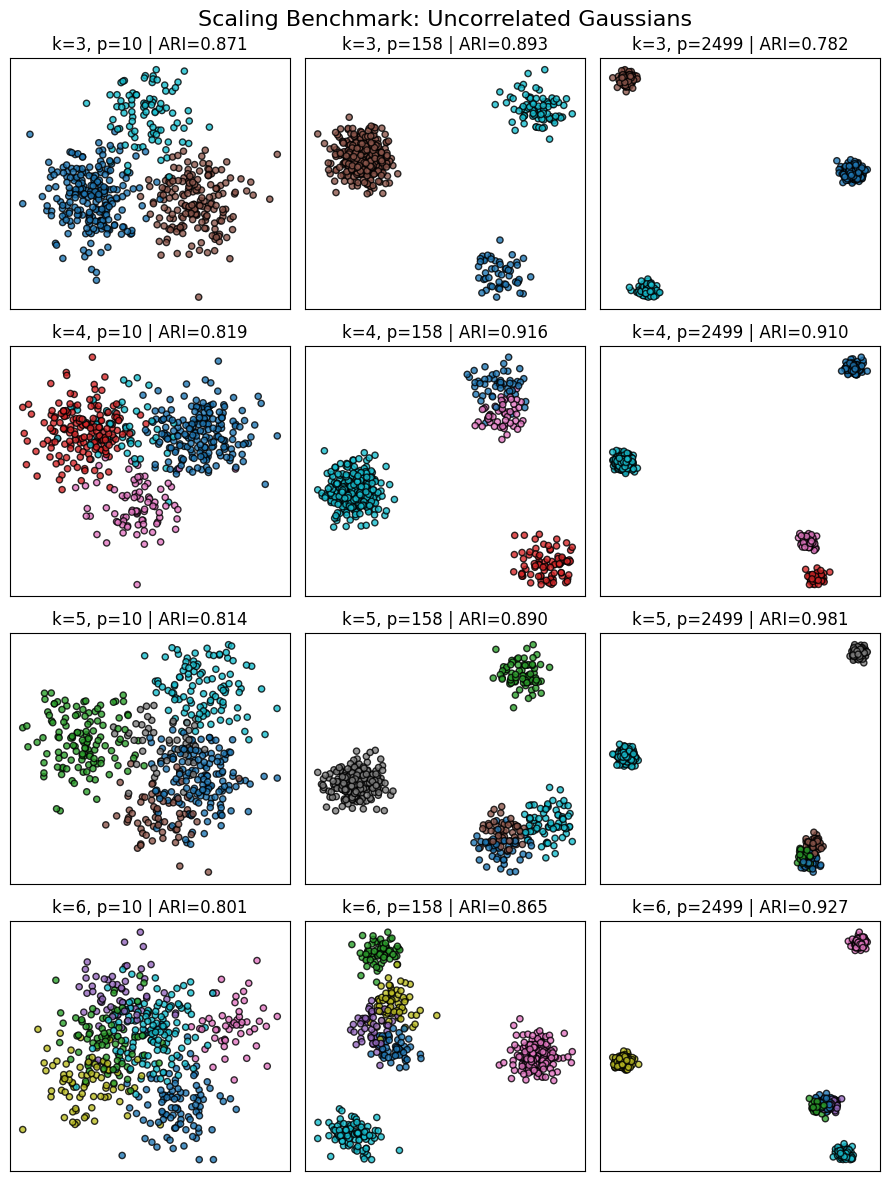

In [23]:
plot_scaling_examples(
    regime=regime_gaussian,
    x_name="p",
    ks=np.array([3, 4, 5, 6]),
    B=5,
    random_state=RADNDOM_SEED,
    estimator_type='kmeans',
    name_of_ex='Uncorrelated Gaussians'
)

In [28]:
results_path = "../results/results_dimensionality_gaussian.csv"
runtime_path = "../results/runtime_dimensionality_gaussian.csv"

if not os.path.exists(results_path):
    results_dimensionality_gaussian, runtime_dimensionality_gaussian = benchmark_scaling(
        regime=regime_gaussian,
        x_name="p",
        B=20,
        model='kmeans',
        true_ks=[3, 4, 5, 6],
        test_ks=range(2, 8),
        random_state=RADNDOM_SEED
    )
    
    os.makedirs("../results/", exist_ok=True)
    results_dimensionality_gaussian.to_csv(results_path, index=False)
    runtime_dimensionality_gaussian.to_csv(runtime_path, index=False)
    
else:
    results_dimensionality_gaussian = pd.read_csv(results_path)
    runtime_dimensionality_gaussian = pd.read_csv(runtime_path)

benchmarking scaling (p):   0%|          | 0/800 [00:00<?, ?it/s]

[CARVE] ============================================================
[CARVE] Validation Settings:
[CARVE] n_samples          : 500
[CARVE] n_features         : 10
[CARVE] K                  : 10
[CARVE] B (resamples)      : 100
[CARVE] rho (subsampling)  : 0.6
[CARVE] n_jobs             : 10
[CARVE] total configs      : 6
[CARVE] random_preprocess  : False
[CARVE] random_state       : 42
[CARVE] ============================================================

[CARVE] Starting validation ...

[CARVE] [1/6] est=KMeans n_clusters=2 | ARI_stab=0.973±0.003  ARI_gen=0.890±0.005  ARI_avg=0.932±0.003
[CARVE] [2/6] est=KMeans n_clusters=3 | ARI_stab=0.742±0.022  ARI_gen=0.681±0.017  ARI_avg=0.712±0.016
[CARVE] [3/6] est=KMeans n_clusters=4 | ARI_stab=0.580±0.010  ARI_gen=0.500±0.008  ARI_avg=0.540±0.007
[CARVE] [4/6] est=KMeans n_clusters=5 | ARI_stab=0.475±0.010  ARI_gen=0.397±0.008  ARI_avg=0.436±0.007
[CARVE] [5/6] est=KMeans n_clusters=6 | ARI_stab=0.418±0.008  ARI_gen=0.328±0.007  ARI_avg=0.3

/Users/kaiwycik/Documents/GitHub/ClusteringValidation/src/carve/_selection.py:106: RuntimeWarning:

No models within quantile thresholds; falling back to max.

/Users/kaiwycik/Documents/GitHub/ClusteringValidation/src/carve/_selection.py:106: RuntimeWarning:

No models within quantile thresholds; falling back to max.



[CARVE] ============================================================
[CARVE] Validation Settings:
[CARVE] n_samples          : 500
[CARVE] n_features         : 34
[CARVE] K                  : 10
[CARVE] B (resamples)      : 100
[CARVE] rho (subsampling)  : 0.6
[CARVE] n_jobs             : 10
[CARVE] total configs      : 6
[CARVE] random_preprocess  : False
[CARVE] random_state       : 46
[CARVE] ============================================================

[CARVE] Starting validation ...

[CARVE] [1/6] est=KMeans n_clusters=2 | ARI_stab=0.363±0.036  ARI_gen=0.300±0.030  ARI_avg=0.331±0.025
[CARVE] [2/6] est=KMeans n_clusters=3 | ARI_stab=0.646±0.022  ARI_gen=0.594±0.021  ARI_avg=0.620±0.017
[CARVE] [3/6] est=KMeans n_clusters=4 | ARI_stab=0.782±0.013  ARI_gen=0.737±0.013  ARI_avg=0.759±0.010
[CARVE] [4/6] est=KMeans n_clusters=5 | ARI_stab=0.844±0.017  ARI_gen=0.849±0.016  ARI_avg=0.846±0.014
[CARVE] [5/6] est=KMeans n_clusters=6 | ARI_stab=0.771±0.009  ARI_gen=0.799±0.010  ARI_avg=0.7

/Users/kaiwycik/Documents/GitHub/ClusteringValidation/src/carve/_selection.py:106: RuntimeWarning:

No models within quantile thresholds; falling back to max.



...

[CARVE] ============================================================
[CARVE] Validation Settings:
[CARVE] n_samples          : 500
[CARVE] n_features         : 116
[CARVE] K                  : 10
[CARVE] B (resamples)      : 100
[CARVE] rho (subsampling)  : 0.6
[CARVE] n_jobs             : 10
[CARVE] total configs      : 6
[CARVE] random_preprocess  : False
[CARVE] random_state       : 60
[CARVE] ============================================================

[CARVE] Starting validation ...

[CARVE] [1/6] est=KMeans n_clusters=2 | ARI_stab=0.844±0.032  ARI_gen=0.832±0.032  ARI_avg=0.838±0.027
[CARVE] [2/6] est=KMeans n_clusters=3 | ARI_stab=0.838±0.015  ARI_gen=0.793±0.016  ARI_avg=0.815±0.011
[CARVE] [3/6] est=KMeans n_clusters=4 | ARI_stab=0.749±0.018  ARI_gen=0.791±0.017  ARI_avg=0.770±0.014
[CARVE] [4/6] est=KMeans n_clusters=5 | ARI_stab=0.680±0.016  ARI_gen=0.717±0.017  ARI_avg=0.699±0.012
[CARVE] [5/6] est=KMeans n_clusters=6 | ARI_stab=0.590±0.010  ARI_gen=0.666±0.014  ARI_avg=0.

/Users/kaiwycik/Documents/GitHub/ClusteringValidation/src/carve/_selection.py:106: RuntimeWarning:

No models within quantile thresholds; falling back to max.



[CARVE] ============================================================
[CARVE] Validation Settings:
[CARVE] n_samples          : 500
[CARVE] n_features         : 214
[CARVE] K                  : 10
[CARVE] B (resamples)      : 100
[CARVE] rho (subsampling)  : 0.6
[CARVE] n_jobs             : 10
[CARVE] total configs      : 6
[CARVE] random_preprocess  : False
[CARVE] random_state       : 53
[CARVE] ============================================================

[CARVE] Starting validation ...

[CARVE] [1/6] est=KMeans n_clusters=2 | ARI_stab=0.829±0.031  ARI_gen=0.740±0.033  ARI_avg=0.784±0.027
[CARVE] [2/6] est=KMeans n_clusters=3 | ARI_stab=0.870±0.017  ARI_gen=0.860±0.016  ARI_avg=0.865±0.013
[CARVE] [3/6] est=KMeans n_clusters=4 | ARI_stab=0.708±0.020  ARI_gen=0.740±0.020  ARI_avg=0.724±0.016
[CARVE] [4/6] est=KMeans n_clusters=5 | ARI_stab=0.510±0.011  ARI_gen=0.592±0.014  ARI_avg=0.551±0.010
[CARVE] [5/6] est=KMeans n_clusters=6 | ARI_stab=0.431±0.006  ARI_gen=0.509±0.011  ARI_avg=0.

/Users/kaiwycik/Documents/GitHub/ClusteringValidation/src/carve/_selection.py:106: RuntimeWarning:

No models within quantile thresholds; falling back to max.

/Users/kaiwycik/Documents/GitHub/ClusteringValidation/src/carve/_selection.py:106: RuntimeWarning:

No models within quantile thresholds; falling back to max.

/Users/kaiwycik/Documents/GitHub/ClusteringValidation/src/carve/_selection.py:106: RuntimeWarning:

No models within quantile thresholds; falling back to max.



[CARVE] ============================================================
[CARVE] Validation Settings:
[CARVE] n_samples          : 500
[CARVE] n_features         : 214
[CARVE] K                  : 10
[CARVE] B (resamples)      : 100
[CARVE] rho (subsampling)  : 0.6
[CARVE] n_jobs             : 10
[CARVE] total configs      : 6
[CARVE] random_preprocess  : False
[CARVE] random_state       : 59
[CARVE] ============================================================

[CARVE] Starting validation ...

[CARVE] [1/6] est=KMeans n_clusters=2 | ARI_stab=0.797±0.037  ARI_gen=0.817±0.037  ARI_avg=0.807±0.031
[CARVE] [2/6] est=KMeans n_clusters=3 | ARI_stab=0.806±0.014  ARI_gen=0.788±0.013  ARI_avg=0.797±0.010
[CARVE] [3/6] est=KMeans n_clusters=4 | ARI_stab=0.785±0.019  ARI_gen=0.830±0.015  ARI_avg=0.807±0.013
[CARVE] [4/6] est=KMeans n_clusters=5 | ARI_stab=0.662±0.018  ARI_gen=0.756±0.019  ARI_avg=0.709±0.015
[CARVE] [5/6] est=KMeans n_clusters=6 | ARI_stab=0.584±0.012  ARI_gen=0.666±0.014  ARI_avg=0.

#### Moons:

In [57]:
regime_moons = {
    3: {"distribution": "moons", "cluster_scale": [6.0, 4.0, 2.0], 'cluster_size_dirichlet_alpha': 0.5, 'balanced': False, 'corr_type': 'ar1', 'corr_strength': 0.5, 'center_box': 2.0},
    4: {"distribution": "moons", "cluster_scale": [8.0, 4.0, 2.0, 1.0], 'cluster_size_dirichlet_alpha': 0.5, 'balanced': False, 'corr_type': 'ar1', 'corr_strength': 0.5, 'center_box': 2.2},
    5: {"distribution": "moons", "cluster_scale": [10.0, 8.0, 4.0, 2.0, 1.0], 'cluster_size_dirichlet_alpha': 0.5, 'balanced': False, 'corr_type': 'ar1', 'corr_strength': 0.5, 'center_box': 2.5},
    6: {"distribution": "moons", "cluster_scale": [12.0, 10.0, 8.0, 4.0, 2.0, 1.0], 'cluster_size_dirichlet_alpha': 0.5, 'balanced': False, 'corr_type': 'ar1', 'corr_strength': 0.5, 'center_box': 2.5}, 
}


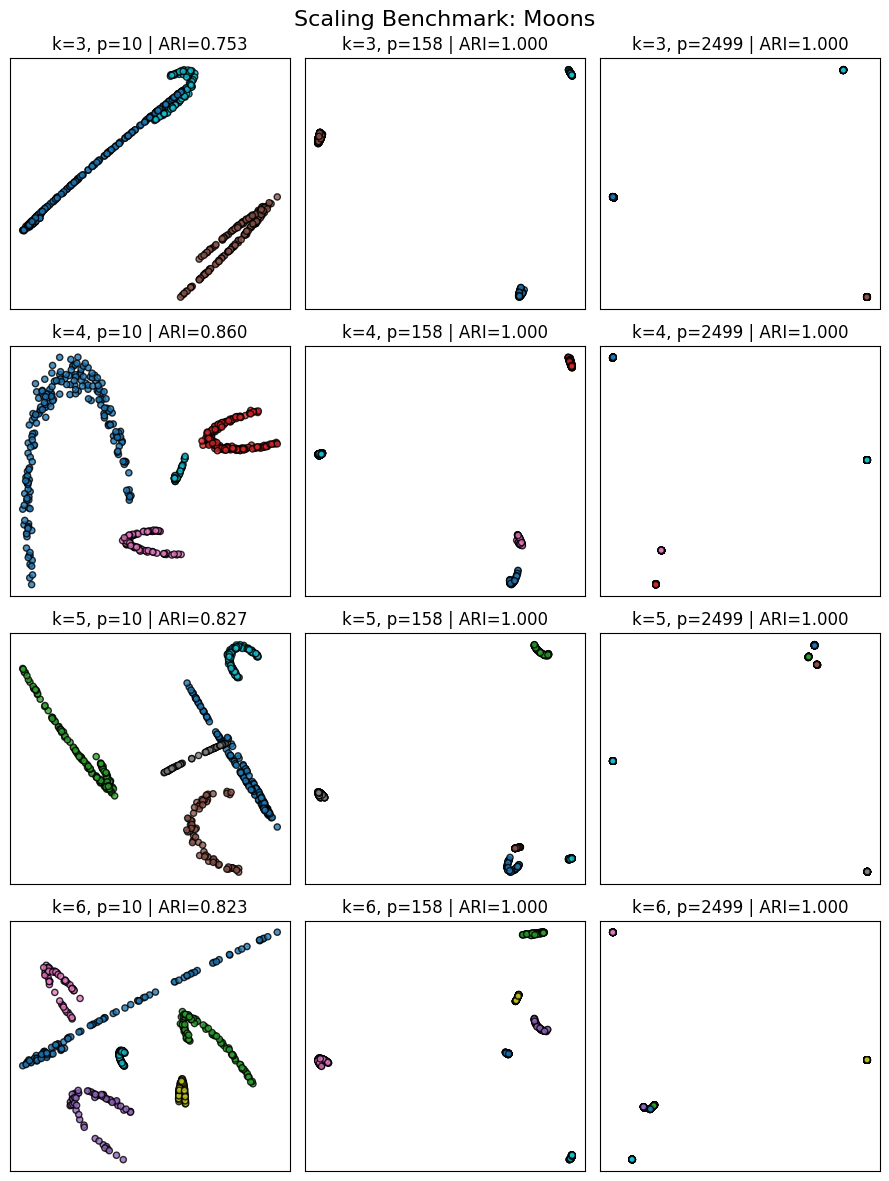

In [58]:
plot_scaling_examples(
    regime=regime_moons,
    x_name="p",
    ks=np.array([3, 4, 5, 6]),
    B=5,
    random_state=RADNDOM_SEED,
    estimator_type='kmeans',
    name_of_ex='Moons'
)

In [59]:
results_path = "../results/results_dimensionality_moons.csv"
runtime_path = "../results/runtime_dimensionality_moons.csv"

if not os.path.exists(results_path):
    results_dimensionality_moons, runtime_dimensionality_moons = benchmark_scaling(
        regime=regime_moons,
        x_name="p",
        B=20,
        model='spectral',
        true_ks=[3, 4, 5, 6],
        test_ks=range(2, 8),
        random_state=RADNDOM_SEED
    )
    
    os.makedirs("../results/", exist_ok=True)
    results_dimensionality_moons.to_csv(results_path, index=False)
    runtime_dimensionality_moons.to_csv(runtime_path, index=False)
    
else:
    results_dimensionality_moons = pd.read_csv(results_path)
    runtime_dimensionality_moons = pd.read_csv(runtime_path)

benchmarking scaling (p):   0%|          | 0/800 [00:00<?, ?it/s]

[CARVE] ============================================================
[CARVE] Validation Settings:
[CARVE] n_samples          : 500
[CARVE] n_features         : 10
[CARVE] K                  : 10
[CARVE] B (resamples)      : 100
[CARVE] rho (subsampling)  : 0.6
[CARVE] n_jobs             : 10
[CARVE] total configs      : 6
[CARVE] random_preprocess  : False
[CARVE] random_state       : 42
[CARVE] ============================================================

[CARVE] Starting validation ...

[CARVE] [1/6] est=SpectralClustering n_clusters=2 | ARI_stab=1.000±0.000  ARI_gen=0.995±0.002  ARI_avg=0.997±0.001
[CARVE] [2/6] est=SpectralClustering n_clusters=3 | ARI_stab=0.959±0.007  ARI_gen=0.917±0.011  ARI_avg=0.938±0.007
[CARVE] [3/6] est=SpectralClustering n_clusters=4 | ARI_stab=0.964±0.006  ARI_gen=0.941±0.008  ARI_avg=0.952±0.005
[CARVE] [4/6] est=SpectralClustering n_clusters=5 | ARI_stab=0.926±0.006  ARI_gen=0.861±0.009  ARI_avg=0.893±0.006
[CARVE] [5/6] est=SpectralClustering n_cluster

/Users/kaiwycik/Documents/GitHub/ClusteringValidation/src/carve/_selection.py:106: RuntimeWarning:

No models within quantile thresholds; falling back to max.



[CARVE] ============================================================
[CARVE] Validation Settings:
[CARVE] n_samples          : 500
[CARVE] n_features         : 10
[CARVE] K                  : 10
[CARVE] B (resamples)      : 100
[CARVE] rho (subsampling)  : 0.6
[CARVE] n_jobs             : 10
[CARVE] total configs      : 6
[CARVE] random_preprocess  : False
[CARVE] random_state       : 42
[CARVE] ============================================================

[CARVE] Starting validation ...

[CARVE] [1/6] est=SpectralClustering n_clusters=2 | ARI_stab=0.989±0.006  ARI_gen=0.950±0.017  ARI_avg=0.969±0.009
[CARVE] [2/6] est=SpectralClustering n_clusters=3 | ARI_stab=0.895±0.014  ARI_gen=0.770±0.018  ARI_avg=0.833±0.012
[CARVE] [3/6] est=SpectralClustering n_clusters=4 | ARI_stab=0.837±0.016  ARI_gen=0.726±0.018  ARI_avg=0.781±0.014
[CARVE] [4/6] est=SpectralClustering n_clusters=5 | ARI_stab=0.859±0.017  ARI_gen=0.770±0.018  ARI_avg=0.814±0.014
[CARVE] [5/6] est=SpectralClustering n_cluster

/Users/kaiwycik/Documents/GitHub/ClusteringValidation/src/carve/_selection.py:106: RuntimeWarning:

No models within quantile thresholds; falling back to max.



...

[CARVE] ============================================================
[CARVE] Validation Settings:
[CARVE] n_samples          : 500
[CARVE] n_features         : 34
[CARVE] K                  : 10
[CARVE] B (resamples)      : 100
[CARVE] rho (subsampling)  : 0.6
[CARVE] n_jobs             : 10
[CARVE] total configs      : 6
[CARVE] random_preprocess  : False
[CARVE] random_state       : 56
[CARVE] ============================================================

[CARVE] Starting validation ...

[CARVE] [1/6] est=SpectralClustering n_clusters=2 | ARI_stab=1.000±0.000  ARI_gen=0.994±0.005  ARI_avg=0.997±0.002
[CARVE] [2/6] est=SpectralClustering n_clusters=3 | ARI_stab=1.000±0.000  ARI_gen=1.000±0.000  ARI_avg=1.000±0.000
[CARVE] [3/6] est=SpectralClustering n_clusters=4 | ARI_stab=0.959±0.004  ARI_gen=0.920±0.006  ARI_avg=0.940±0.004
[CARVE] [4/6] est=SpectralClustering n_clusters=5 | ARI_stab=0.950±0.005  ARI_gen=0.898±0.008  ARI_avg=0.924±0.005
[CARVE] [5/6] est=SpectralClustering n_cluster

/Users/kaiwycik/Documents/GitHub/ClusteringValidation/src/carve/_selection.py:106: RuntimeWarning:

No models within quantile thresholds; falling back to max.

/Users/kaiwycik/Documents/GitHub/ClusteringValidation/src/carve/_selection.py:106: RuntimeWarning:

No models within quantile thresholds; falling back to max.



[CARVE] ============================================================
[CARVE] Validation Settings:
[CARVE] n_samples          : 500
[CARVE] n_features         : 732
[CARVE] K                  : 10
[CARVE] B (resamples)      : 100
[CARVE] rho (subsampling)  : 0.6
[CARVE] n_jobs             : 10
[CARVE] total configs      : 6
[CARVE] random_preprocess  : False
[CARVE] random_state       : 58
[CARVE] ============================================================

[CARVE] Starting validation ...

[CARVE] [1/6] est=SpectralClustering n_clusters=2 | ARI_stab=1.000±0.000  ARI_gen=1.000±0.000  ARI_avg=1.000±0.000
[CARVE] [2/6] est=SpectralClustering n_clusters=3 | ARI_stab=0.917±0.008  ARI_gen=0.858±0.005  ARI_avg=0.888±0.004
[CARVE] [3/6] est=SpectralClustering n_clusters=4 | ARI_stab=1.000±0.000  ARI_gen=1.000±0.000  ARI_avg=1.000±0.000
[CARVE] [4/6] est=SpectralClustering n_clusters=5 | ARI_stab=0.968±0.004  ARI_gen=0.933±0.006  ARI_avg=0.950±0.004
[CARVE] [5/6] est=SpectralClustering n_cluste

/Users/kaiwycik/Documents/GitHub/ClusteringValidation/src/carve/_selection.py:106: RuntimeWarning:

No models within quantile thresholds; falling back to max.

/Users/kaiwycik/Documents/GitHub/ClusteringValidation/src/carve/_selection.py:106: RuntimeWarning:

No models within quantile thresholds; falling back to max.



[CARVE] ============================================================
[CARVE] Validation Settings:
[CARVE] n_samples          : 500
[CARVE] n_features         : 2499
[CARVE] K                  : 10
[CARVE] B (resamples)      : 100
[CARVE] rho (subsampling)  : 0.6
[CARVE] n_jobs             : 10
[CARVE] total configs      : 6
[CARVE] random_preprocess  : False
[CARVE] random_state       : 59
[CARVE] ============================================================

[CARVE] Starting validation ...

[CARVE] [1/6] est=SpectralClustering n_clusters=2 | ARI_stab=1.000±0.000  ARI_gen=1.000±0.000  ARI_avg=1.000±0.000
[CARVE] [2/6] est=SpectralClustering n_clusters=3 | ARI_stab=0.979±0.005  ARI_gen=0.969±0.006  ARI_avg=0.974±0.004
[CARVE] [3/6] est=SpectralClustering n_clusters=4 | ARI_stab=1.000±0.000  ARI_gen=1.000±0.000  ARI_avg=1.000±0.000
[CARVE] [4/6] est=SpectralClustering n_clusters=5 | ARI_stab=0.972±0.003  ARI_gen=0.950±0.004  ARI_avg=0.961±0.002
[CARVE] [5/6] est=SpectralClustering n_clust

---